In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['OMP_NUM_THREADS'] = '8' # Force the system to allocate 8 threads to OpenMP
os.environ['NGS_NUM_THREADS'] = '8' # Force NGSolve's internal task manager to use 8 threads
import ngsolve as ngs
ngs.SetNumThreads(8)

current_dir=  /Home/RB286887/LH_coupling_code_remi/aloha_fem
--- Configuration successfully loaded and validated from inputs/input.yaml ---
--- Pre-Run Blueprint Verification (PAM) ---


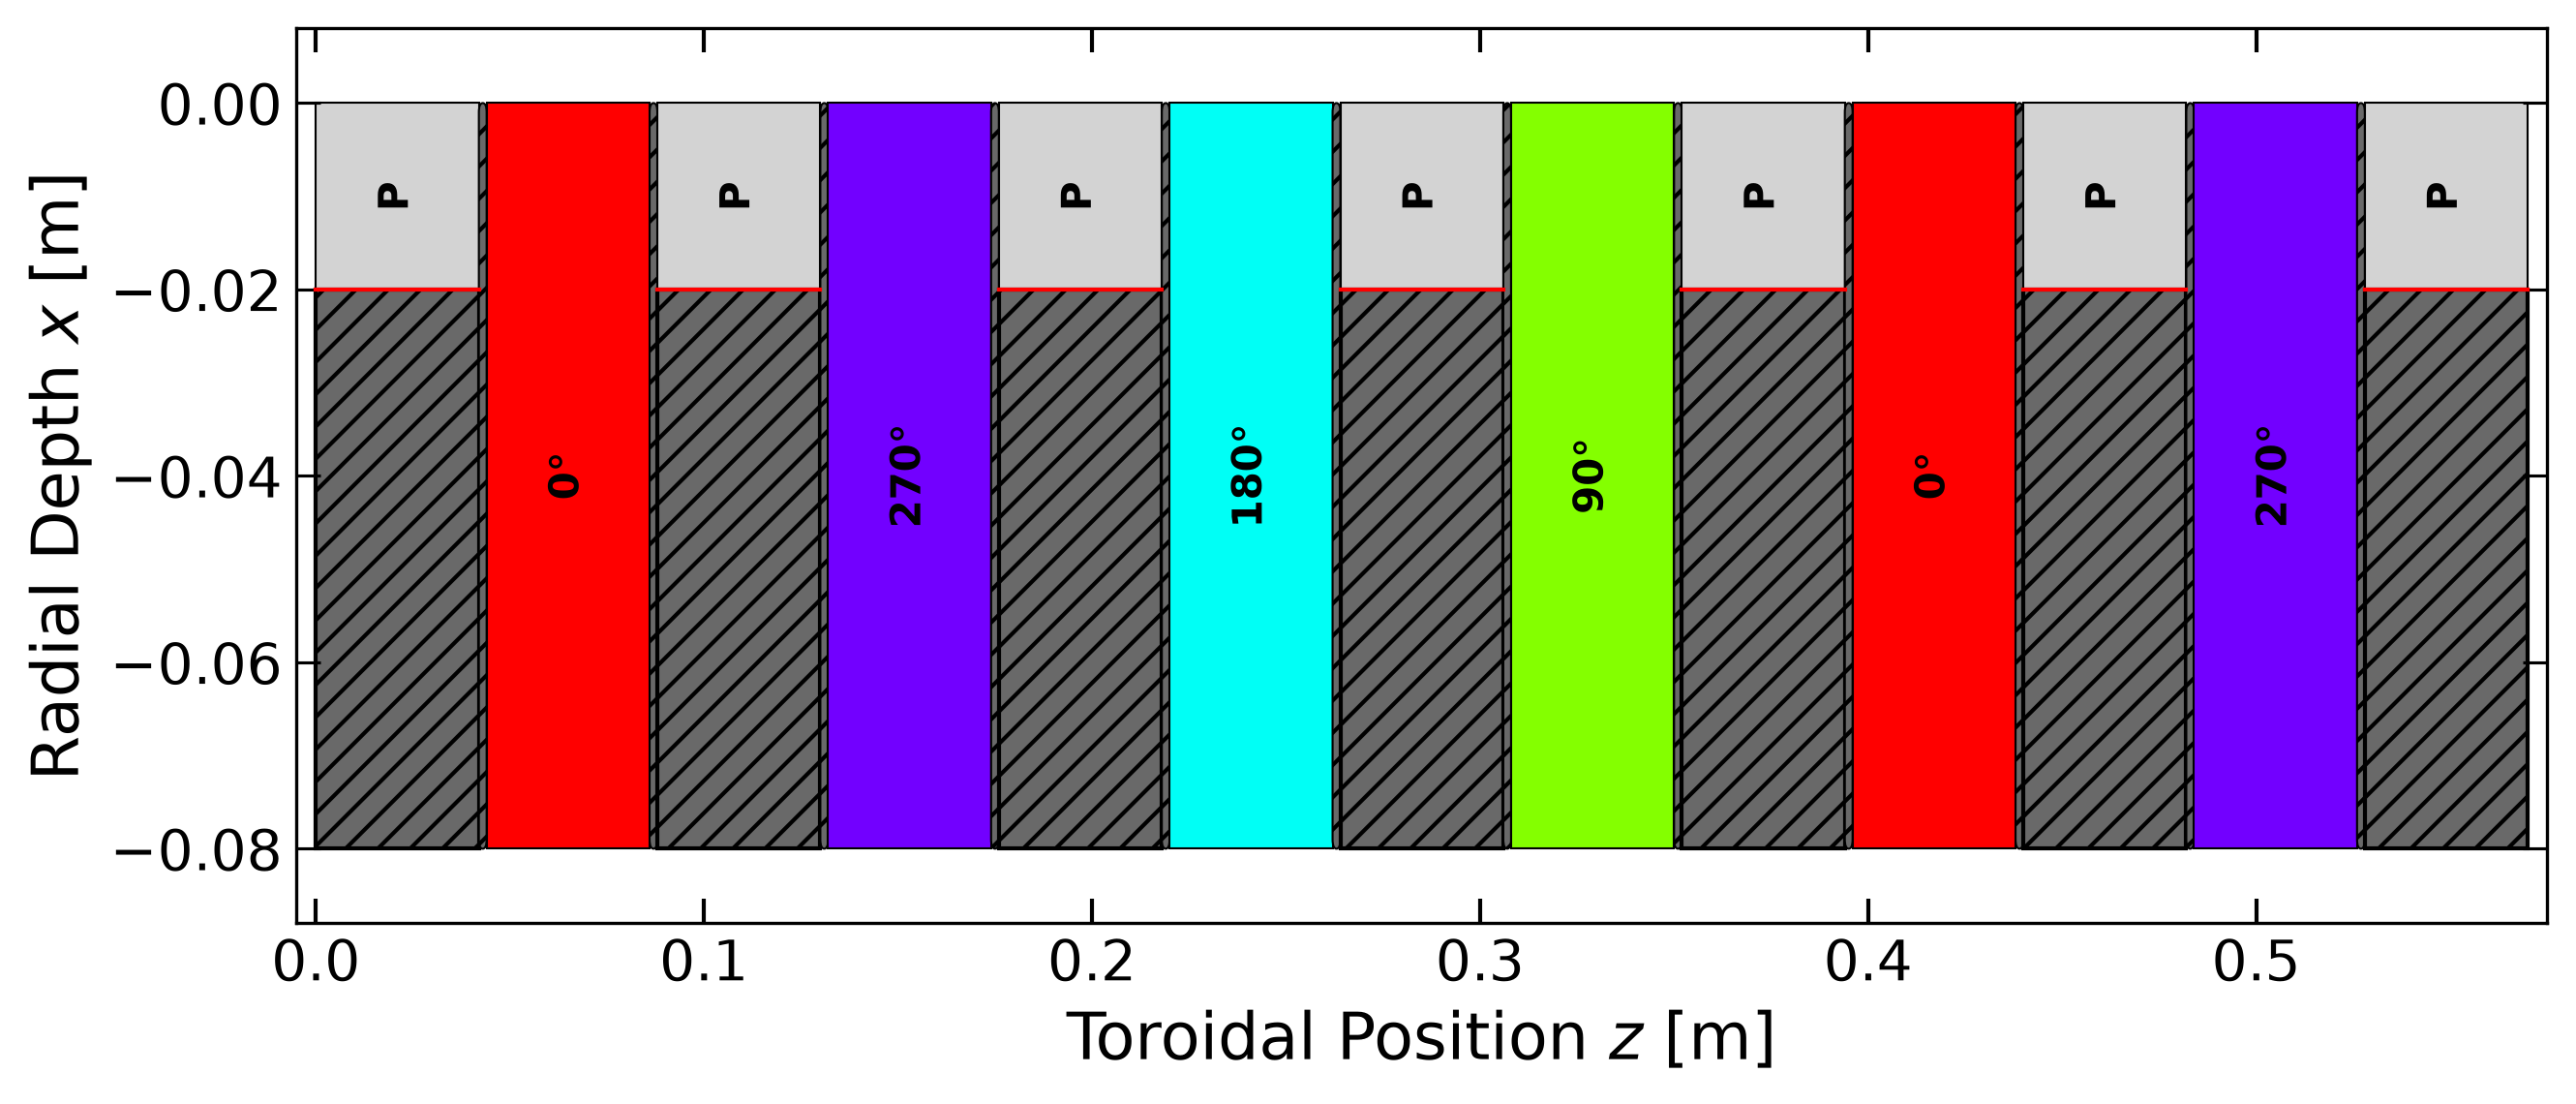

In [2]:
current_dir = os.path.abspath(".")
print('current_dir= ', current_dir)
if current_dir not in sys.path:
    sys.path.append(current_dir)

from config.config_loader import load_config
from postprocessing.plot_curves import plot_blueprint_from_yaml

input_config = load_config("inputs/input.yaml")
# Run the pre-check plot
plot_blueprint_from_yaml("inputs/input.yaml")

In [5]:
import os
import numpy as np

from config.schema import SimulationConfig
from core.mesh_builder import MeshFactory, MeshBuilder2D
from core.solver2D import FEMSolver2D

from physics import stix, pml, waveguide
shortest_lambda=0.01 # test
mesh = MeshFactory.build(input_config, shortest_lambda)

stix_physics = stix.StixPhysics(input_config)
pml_physics = pml.JacquotPML(input_config)
wg_physics = waveguide.WaveguidePhysics(input_config)

print('Solving Start')
solver = FEMSolver2D(input_config, mesh, stix_physics, pml_physics, wg_physics)
solver.solve()
print('Solving End')

base_maxh=0.002
pml_maxh=0.001
Solving Start
dom n_// : 2.0
==== #DoFs = 1889714
admittance computed,
 function spaces set up, 
 physics tensor built
--- Weak Form Assembly ---
--- System Solved ---
Solving End



--- Extracting Rigorous S-Parameters ---
  -> WG_1 | |Gamma|^2 = 0.8068 | Phase = -176.7°
  -> WG_2 | |Gamma|^2 = 0.8267 | Phase = -175.8°
  -> WG_3 | |Gamma|^2 = 0.8544 | Phase = -176.8°
  -> WG_4 | |Gamma|^2 = 0.8246 | Phase = -175.1°
  -> WG_5 | |Gamma|^2 = 0.9154 | Phase = -177.7°
  -> WG_6 | |Gamma|^2 = 0.7812 | Phase = -175.2°

--- Extracting Field Profile at x=0.0100 m ---
--- Computing Normalized Power Spectrum (ALOHA Benchmark) ---
  -> Total Net Coupled Power: 9.9085e-01 W

--- Exporting HDF5 Database to /Home/RB286887/LH_coupling_code_remi/aloha_fem/sim_results/run_20260731_153456.h5 ---


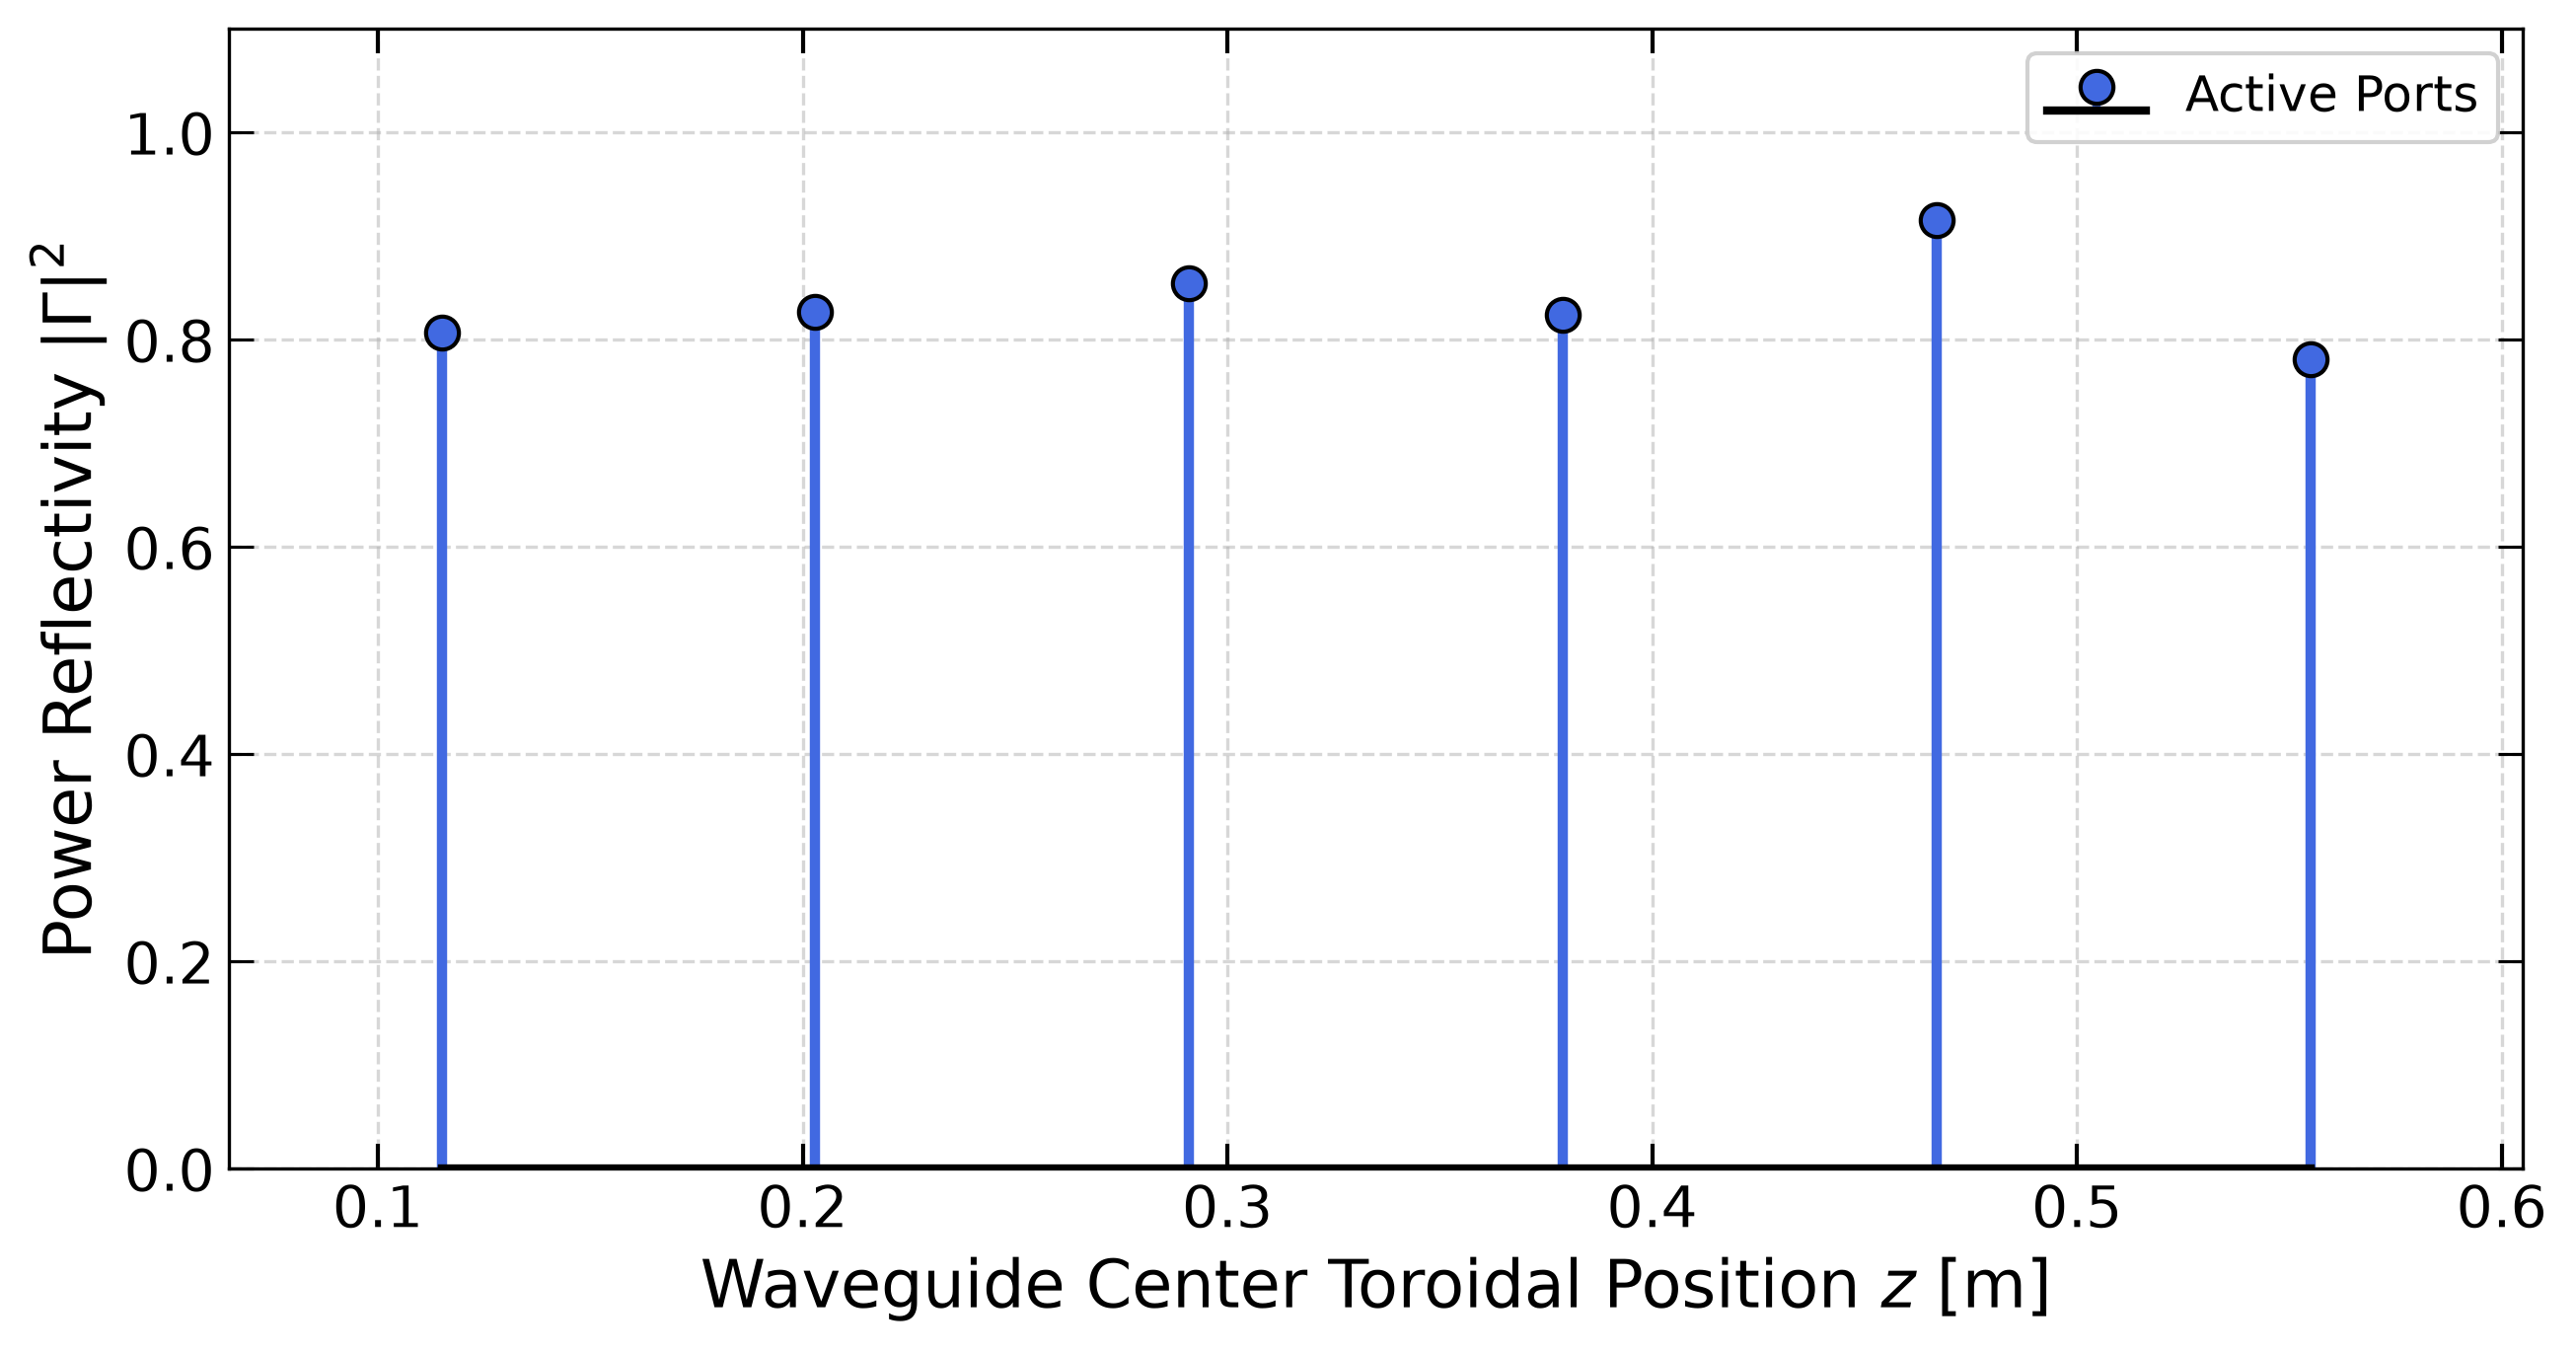

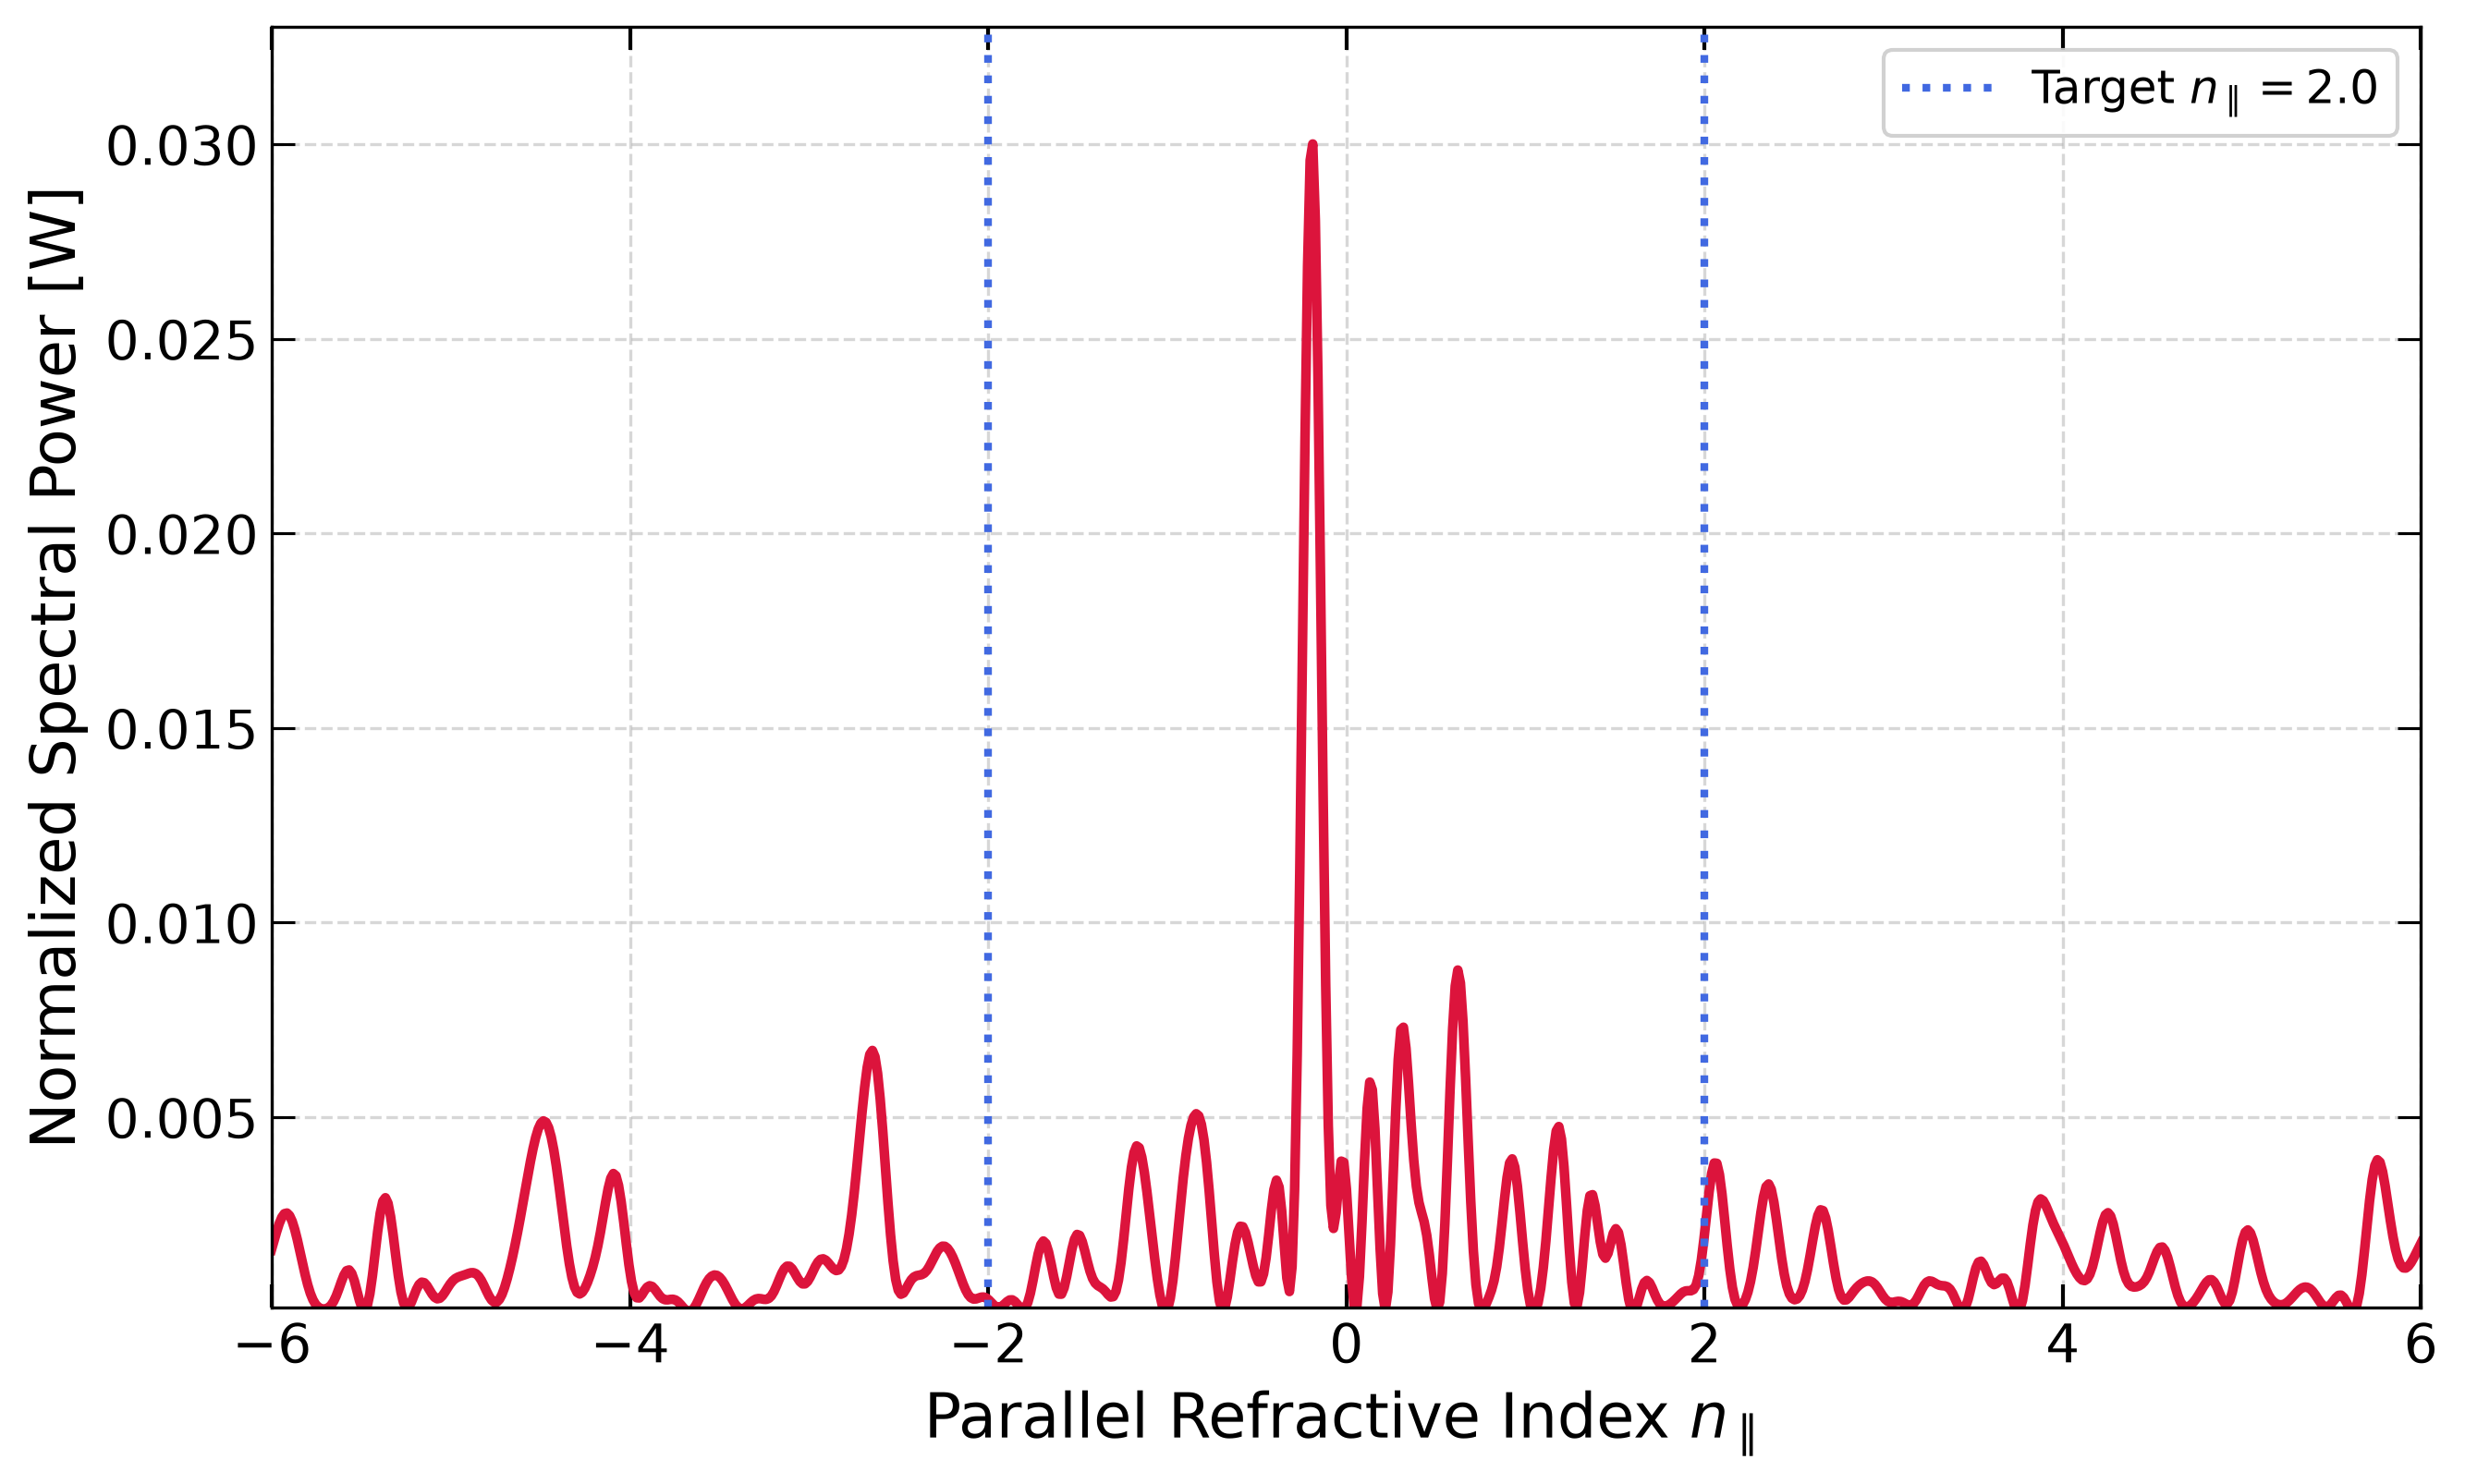

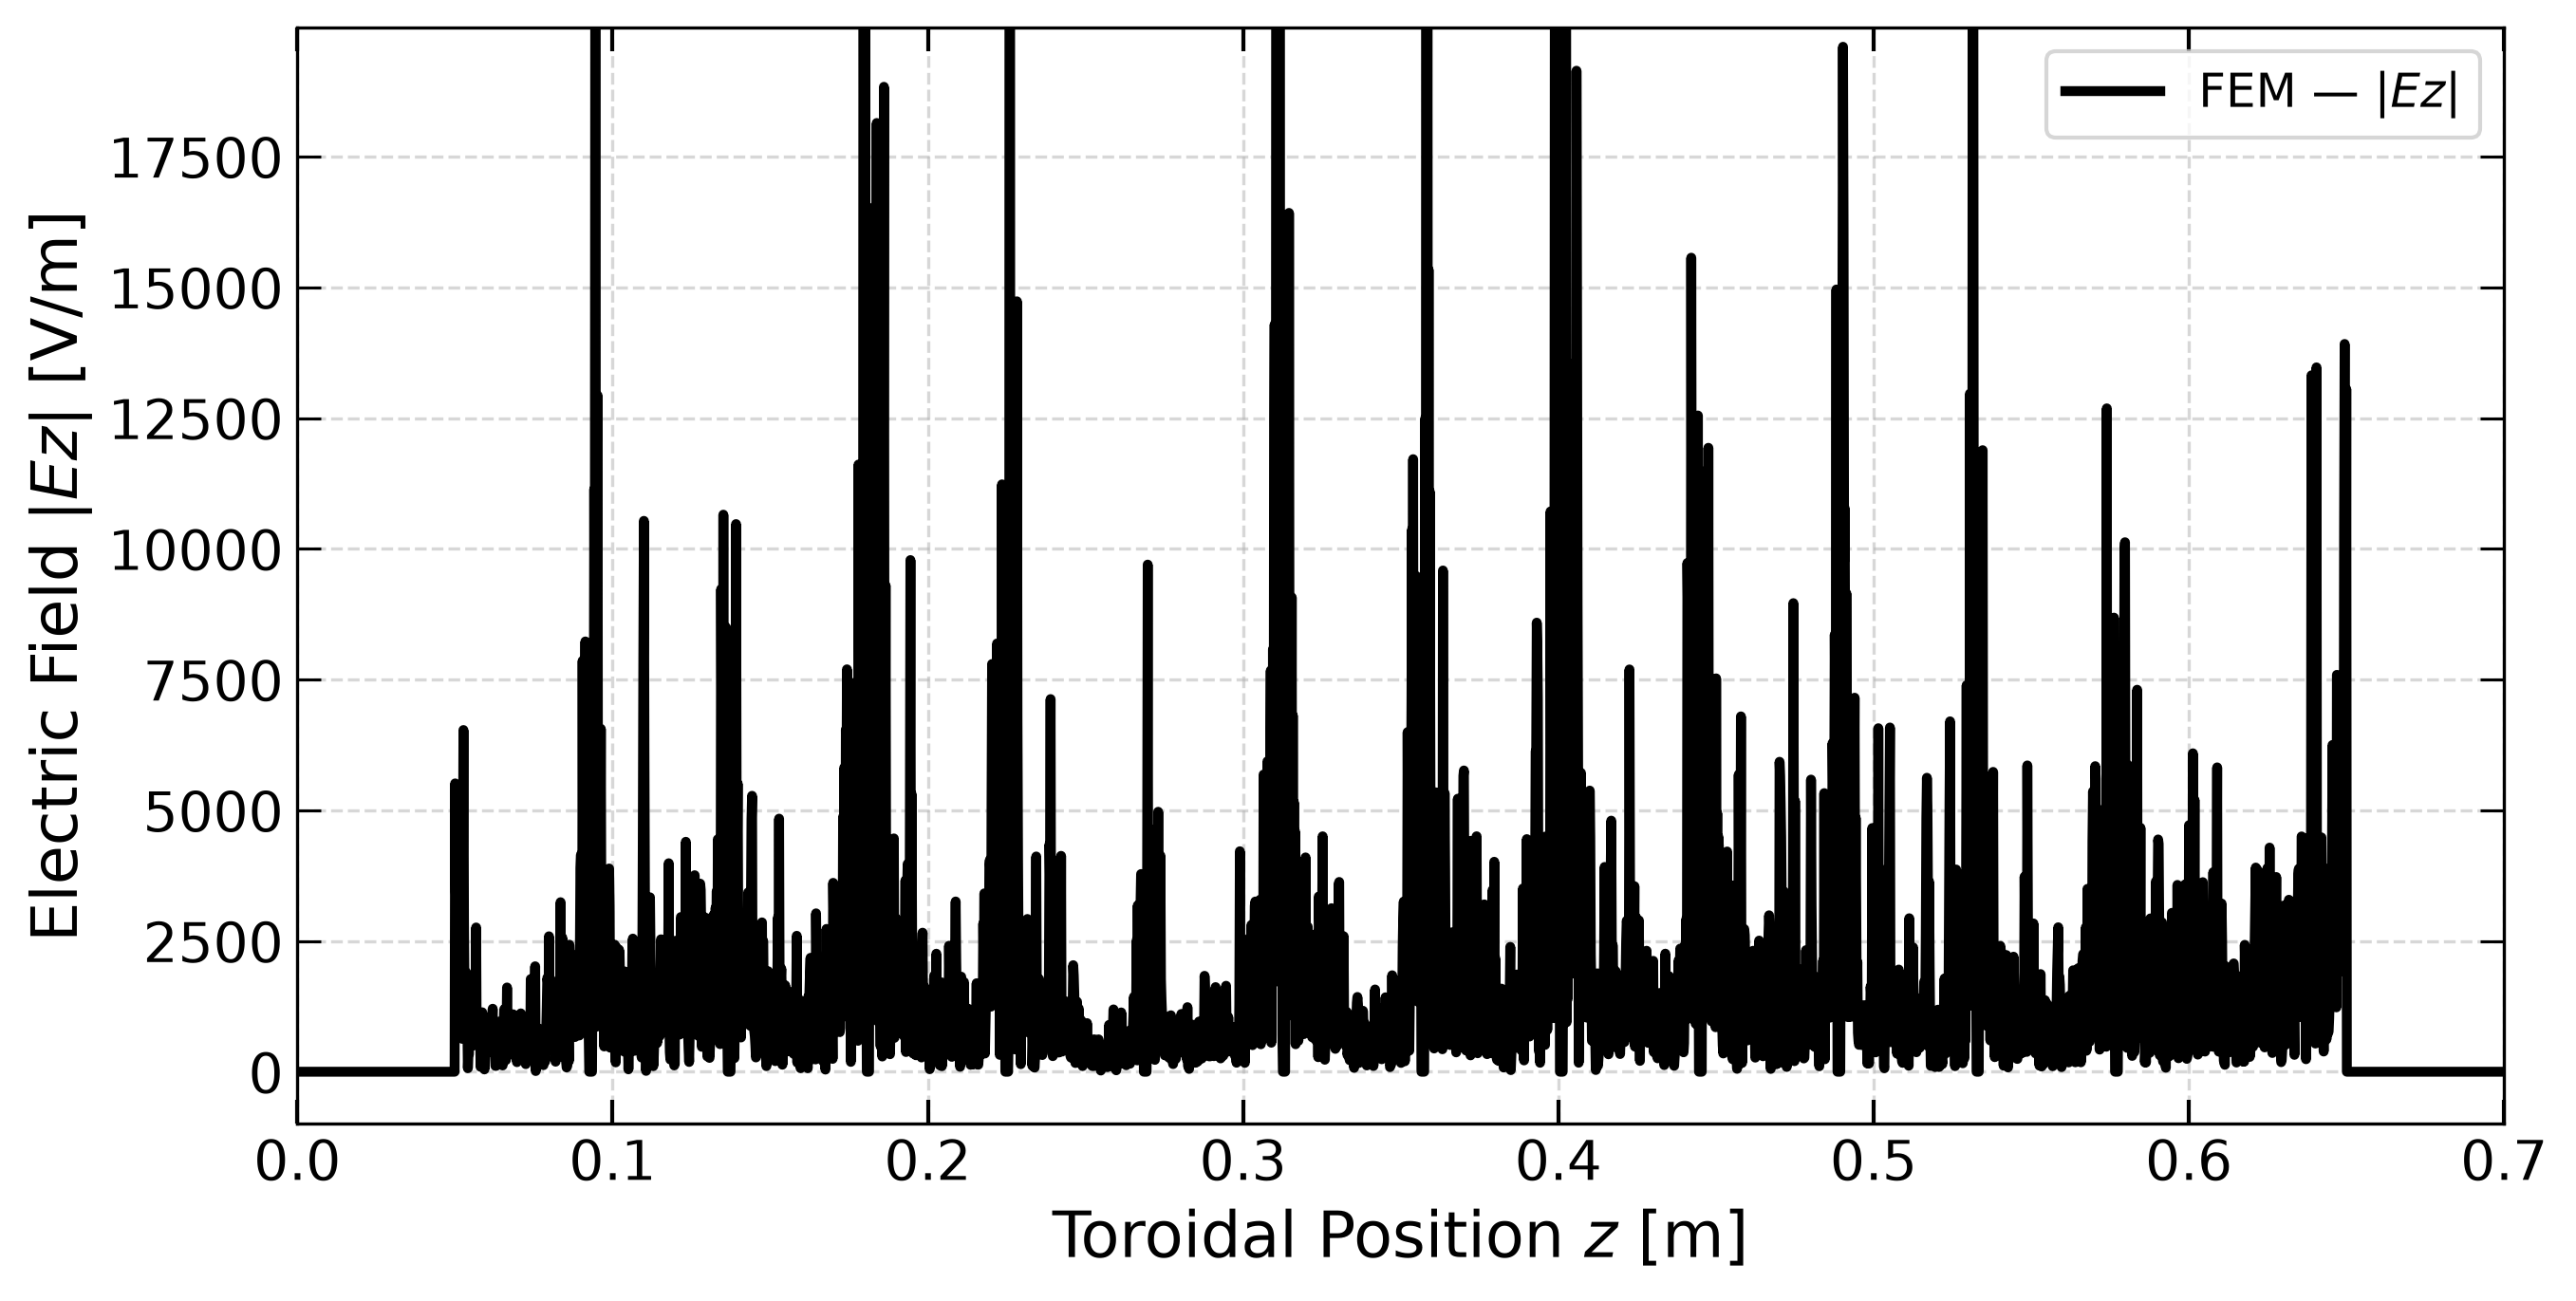

[!] No 2D map data found in HDF5 file.


In [8]:
from core.diagnostics import DiagnosticManager

diag = DiagnosticManager(solver, output_dir="/Home/RB286887/LH_coupling_code_remi/aloha_fem/sim_results")
gamma_dict = diag.extract_s_parameters()
field_data = diag.extract_toroidal_field_profile(x_target=0.01)
n_para, dP_dn = diag.compute_power_spectrum(field_data, gamma_dict)

diag.export_hdf5_database(
    custom_prefix="run",
    save_data=True,
    gamma_dict=gamma_dict,
    field_data=field_data,
    spectrum_data=(n_para, dP_dn)
)
from postprocessing.data_reader import SimulationData
from postprocessing.plot_curves import plot_s_parameters, plot_power_spectrum, plot_aperture_field_amplitude

sim_data = SimulationData("sim_results/run_20260731_153350.h5")
plot_s_parameters(sim_data, save_dir="sim_results")
plot_power_spectrum(sim_data, save_dir="sim_results")
plot_aperture_field_amplitude(sim_data, component="Ez", save_dir="sim_results")

from postprocessing.plot_maps import plot_2D_wave_map
plot_2D_wave_map(sim_data, component='Ez', value_type='real', save_dir="sim_results")